# Libraries

In [1]:
import pandas as pd

import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel(r"C:\Users\DELL\OneDrive\Desktop\Python_Projects\Merged_dataset.xlsx")
exc_copied = df.copy()
exc_copied

,Reference_ID,Given_Name,Last_Name,Departments,Received_At,University,Citizenship,Intake,Phone_Number,Street_1,...,Program_Of_interest,Term,Global_Grad_Indicator,Deposit_Paid,Accepted_Admission,Person_Email,I_901_Status,Contact_Number,Student_Status,Remarks
0,1289258,Adekunle,Adefowoju,BusinessAdministration(MBA)ProfessionalMBA(Eve...,1970-01-01 00:29:04.630,Saint Louis University,Nigeria,Fall 2024,2350000000000,"9,HappinessEstateOffAmuleBusStopAyoboIpajaLago...",...,Other,Other,Not_Recorded,Not_Recorded,Not_Recorded,Not_Recorded,Other,Not_Recorded,Other,Other
1,1294844,Emmanuel,AduNyarko,Analytics(MS)atSaintLouis,1970-01-01 00:29:04.630,Saint Louis University,Ghana,Fall 2024,233000000000,Plot11KwadwoAdjeistreet,...,Other,Other,Not_Recorded,Not_Recorded,Not_Recorded,Not_Recorded,Other,Not_Recorded,Other,Other
2,1302877,Ogochukwu,Agina,Analytics(MS)atSaintLouis,1970-01-01 00:29:04.630,Saint Louis University,Nigeria,Fall 2024,2350000000000,DClose206Road,...,Analytics (MS),Fall 2024,Yes,Yes,Yes,o.agina@gmail.com,Payment,7037993011,Outreach efforts,Not connected
3,1299192,Afia,AgyapongAnsong,InformationSystems(MS)atSaintLouis,1970-01-01 00:29:04.630,Saint Louis University,Ghana,Fall 2024,234000000000,45NiiTsawest,...,Other,Other,Not_Recorded,Not_Recorded,Not_Recorded,Not_Recorded,Other,Not_Recorded,Other,Other
4,1324269,RebeccaAgyeiwaa,Agyare,PublicHealth(MPH)EpidemiologyatSaintLouis,1970-01-01 00:29:04.630,Saint Louis University,Ghana,Fall 2024,234000000000,GbaweCConnieTaxiRank,...,Public Health (MPH),Fall 2024,No,Yes,Yes,rebeccaagyare67@gmail.com,Payment,233553468259,Visa approved,Not provided
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6888,1424285,Avinash,Jha,Cybersecurity (MS),1970-01-01 00:29:08.330,Saint Louis University,Nepal,Fall 2026,+977 981-7895320,Kadam Chowk -2,...,Other,Other,Not_Recorded,Not_Recorded,Not_Recorded,Not_Recorded,Other,Not_Recorded,Other,Other
6889,1440172,Samuel Opeyemi,Olabintan,Biomedical Engineering (PHD),1970-01-01 00:29:08.330,Saint Louis University,Nigeria,Fall 2026,+234 701 908 6202,"28,Fabukade Street,Shogunle",...,Other,Other,Not_Recorded,Not_Recorded,Not_Recorded,Not_Recorded,Other,Not_Recorded,Other,Other
6890,1356764,Ama,Essel,Project Management (MS),1970-01-01 00:29:08.330,Saint Louis University,Ghana,Fall 2026,+233 24 808 6344,"C/O Jei River, Kasoa",...,Other,Other,Not_Recorded,Not_Recorded,Not_Recorded,Not_Recorded,Other,Not_Recorded,Other,Other
6891,1381727,Jonathan,Cobbina,Information Systems (MS),1970-01-01 00:29:08.330,Saint Louis University,Ghana,Fall 2026,+233 55 673 0711,CG0209-5667,...,Other,Other,Not_Recorded,Not_Recorded,Not_Recorded,Not_Recorded,Other,Not_Recorded,Other,Other


# EDA

In [3]:
exc_copied.shape

(6893, 71)

In [4]:
exc_copied.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6893 entries, 0 to 6892
Data columns (total 71 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Reference_ID                       6893 non-null   int64         
 1   Given_Name                         6893 non-null   object        
 2   Last_Name                          6893 non-null   object        
 3   Departments                        6893 non-null   object        
 4   Received_At                        6893 non-null   datetime64[ns]
 5   University                         6893 non-null   object        
 6   Citizenship                        6893 non-null   object        
 7   Intake                             6893 non-null   object        
 8   Phone_Number                       6893 non-null   object        
 9   Street_1                           6893 non-null   object        
 10  City                               6

In [41]:
exc_copied['Phone_Number'].unique()

array([2350000000000, 233000000000, 234000000000, ..., '+233 24 808 6344',
       '+233 55 673 0711', '+1 623-283-7260'], shape=(6734,), dtype=object)

In [ ]:
exc_copied['Phone_Number'] = (
    exc_copied['Phone_Number']
    .astype(str)
    .str.replace(r'[+\s-]', '', regex=True)
)

In [43]:
exc_copied['Contact_Number'] = (
    exc_copied['Contact_Number']
    .astype(str)
    .str.replace(r'[+\s-]', '', regex=True)
)

In [34]:
exc_copied.rename(columns = {"Student's_Personal_Funds": "Student_Personal_Funds"}, inplace = True) 

In [54]:
exc_copied.drop('Phone_Number', axis= 1, inplace=True)
exc_copied.drop('Contact_Number', axis= 1, inplace=True)

In [6]:
# Cleaning Other Source Type 

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Student Loan', 'Other_Source_Type'] = 'Student loan'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'student loan', 'Other_Source_Type'] = 'Student loan'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'education loan', 'Other_Source_Type'] = 'Student loan'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'MPOWER Financing Student Loan', 'Other_Source_Type'] = 'Student loan'


exc_copied.loc[exc_copied['Other_Source_Type'] == 'Loan', 'Other_Source_Type'] = 'Student loan'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Educational loan', 'Other_Source_Type'] = 'Student loan'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'student loans', 'Other_Source_Type'] = 'Student loan'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Al-Baha University', 'Other_Source_Type'] = 'Student loan'


exc_copied.loc[exc_copied['Other_Source_Type'] == 'AVANSE Student Loan', 'Other_Source_Type'] = 'Student loan'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'ProconnectPAY EduInvestment Scheme', 'Other_Source_Type'] = 'Student loan'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Educational Loan', 'Other_Source_Type'] = 'Student loan'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Personal Student Loan: Mpower Financing', 'Other_Source_Type'] = 'Student loan'


#exc_copied.loc[exc_copied['Other_Source_Type'] == 'Student loan', 'Other_Source_Type'] = 'Student loan'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Personal Student Loan - Mpower Financing', 'Other_Source_Type'] = 'Student loan'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Prodigy Finance Loan', 'Other_Source_Type'] = 'Student loan'


exc_copied.loc[exc_copied['Other_Source_Type'] == 'St. Ann Catholic Church', 'Other_Source_Type'] = 'Student loan'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'St Josephine Bakhita Catholic Church', 'Other_Source_Type'] = 'Student loan'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Prestea Huni Valley Municipal Assembly', 'Other_Source_Type'] = 'Student loan'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Unique Care Hospital Clinic and Maternity', 'Other_Source_Type'] = 'Student loan'




exc_copied.loc[exc_copied['Other_Source_Type'] == 'Family Funds, Student Loan', 'Other_Source_Type'] = 'Family funded and student loan'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'student loans + family funded from mother Adebayo Dorcas Kuburat', 'Other_Source_Type'] = 'Family funded and student loan'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Family funds and HDFC CREDILA Loan', 'Other_Source_Type'] = 'Family funded and student loan'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Family Funds and Loan', 'Other_Source_Type'] = 'Family funded and student loan'


exc_copied.loc[exc_copied['Other_Source_Type'] == 'education loan and family funding', 'Other_Source_Type'] = 'Family funded and student loan'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Family Funds and Ekiti State Scholarship', 'Other_Source_Type'] = 'Family funded and student loan'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Prodigy Finance Student Loan and Family Funds', 'Other_Source_Type'] = 'Family funded and student loan'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Prodigy Loan and Mother', 'Other_Source_Type'] = 'Family funded and student loan'


exc_copied.loc[exc_copied['Other_Source_Type'] == 'Student Loan and Husband', 'Other_Source_Type'] = 'Family funded and student loan'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Family Funding + Student Loan', 'Other_Source_Type'] = 'Family funded and student loan'

exc_copied.loc[exc_copied['Other_Source_Type'] == '$19600 Father, $50000 MPower Loan', 'Other_Source_Type'] = 'Family funded and student loan'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Family Funds and Student Loan', 'Other_Source_Type'] = 'Family funded and student loan'


exc_copied.loc[exc_copied['Other_Source_Type'] == 'Ybizii Technologies and family funds', 'Other_Source_Type'] = 'Family funded and student loan'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Student loan/Family funds', 'Other_Source_Type'] = 'Family funded and student loan'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Family Funds and MPOWER Financing Student Loan', 'Other_Source_Type'] = 'Family funded and student loan'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Student loan/Yusuf Amuda', 'Other_Source_Type'] = 'Family funded and student loan'






exc_copied.loc[exc_copied['Other_Source_Type'] == 'Family Funds', 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Tutor', 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Sponsor: Emmanuel Buckner', 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Spouse', 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Mother', 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'family funded', 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'family funding', 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'family funds', 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'S. E. Auto Ltd.', 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Family funds', 'Other_Source_Type'] = 'Family funded'


exc_copied.loc[exc_copied['Other_Source_Type'] == 'Family Funding', 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'James Kwabena Asenso', 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Family-funded', 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Family funding', 'Other_Source_Type'] = 'Family funded'


exc_copied.loc[exc_copied['Other_Source_Type'] == 'Mohamed Eloliby', 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Sponsor:Kusemererwa Jovan', 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'supported by husband, Machavarapu Eswar Kumar', 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Padma Rilapur', 'Other_Source_Type'] = 'Family funded'


exc_copied.loc[exc_copied['Other_Source_Type'] == "family funded by student's mother, Srigiri Jedidah Doris", 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Sponsor: Ashok Magam', 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Tran Minh Thoa', 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Sponsor: Kandula Uday Kumar', 'Other_Source_Type'] = 'Family funded'


exc_copied.loc[exc_copied['Other_Source_Type'] == 'Sponsor: Waqar Ullah', 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Isatou Bah', 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == "Family funded by student's step father, Benjamin Amoani", 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Sponsor: Jacklyn Ramat Adjei', 'Other_Source_Type'] = 'Family funded'


exc_copied.loc[exc_copied['Other_Source_Type'] == "family funded by student's maternal uncle, Andrew Muyonga Mubiru", 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Employer funds', 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Gyimah Gabriel Oburoni', 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Sister - Francisca Ebinum', 'Other_Source_Type'] = 'Family funded'


exc_copied.loc[exc_copied['Other_Source_Type'] == "SPOUSE", 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'student is financially supported by thier uncle-- Stephen Walter Acquah', 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == "family funded by student's brother-- Kenneth Gyan", 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Uncle - Zekarias Dagne Bulto', 'Other_Source_Type'] = 'Family funded'


exc_copied.loc[exc_copied['Other_Source_Type'] == "Sponsor: Sammy Changwony Kipchirchir", 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Adekunle Lawal', 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Sponsor: Johnny Ungwugwaye Agim', 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Benjamin Antwi-- Uncle', 'Other_Source_Type'] = 'Family funded'


exc_copied.loc[exc_copied['Other_Source_Type'] == "Sponsor: Olanike Ibitunde", 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Michael Kyeremateng', 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == "family funded by Om Bharatkumar Patel", 'Other_Source_Type'] = 'Family funded'

exc_copied.loc[exc_copied['Other_Source_Type'] == 'Husband', 'Other_Source_Type'] = 'Family funded'


In [36]:
print("\nDescriptive statistics of numerical variables:")

print(exc_copied[[
    'Age','Tuition_Fees','Living_Expenses',
    'Dependent_Expenses','Other_Costs', "Student_Personal_Funds",
    "Funds_From_This_School", "Funds_From_Other_Sources", 'I-901_Transaction_Amount'
    ]].describe().round(2))


Descriptive statistics of numerical variables:
           Age  Tuition_Fees  Living_Expenses  Dependent_Expenses  \
count  6893.00       6893.00          6893.00             6893.00   
mean     28.29      21986.71         17982.12              264.13   
std       5.81       1327.33           191.54              529.91   
min       1.00      11700.00          8250.00                0.00   
25%      24.00      21986.71         17982.12              264.13   
50%      27.00      21986.71         17982.12              264.13   
75%      31.00      21986.71         17982.12              264.13   
max      74.00      55500.00         18150.00            16000.00   

       Other_Costs  Student_Personal_Funds  Funds_From_This_School  \
count      6893.00                 6893.00                 6893.00   
mean         12.52                 5964.13                 3655.98   
std          73.14                 4483.63                 2550.06   
min           0.00                    0.00        


Boxplot of Numerical variables:


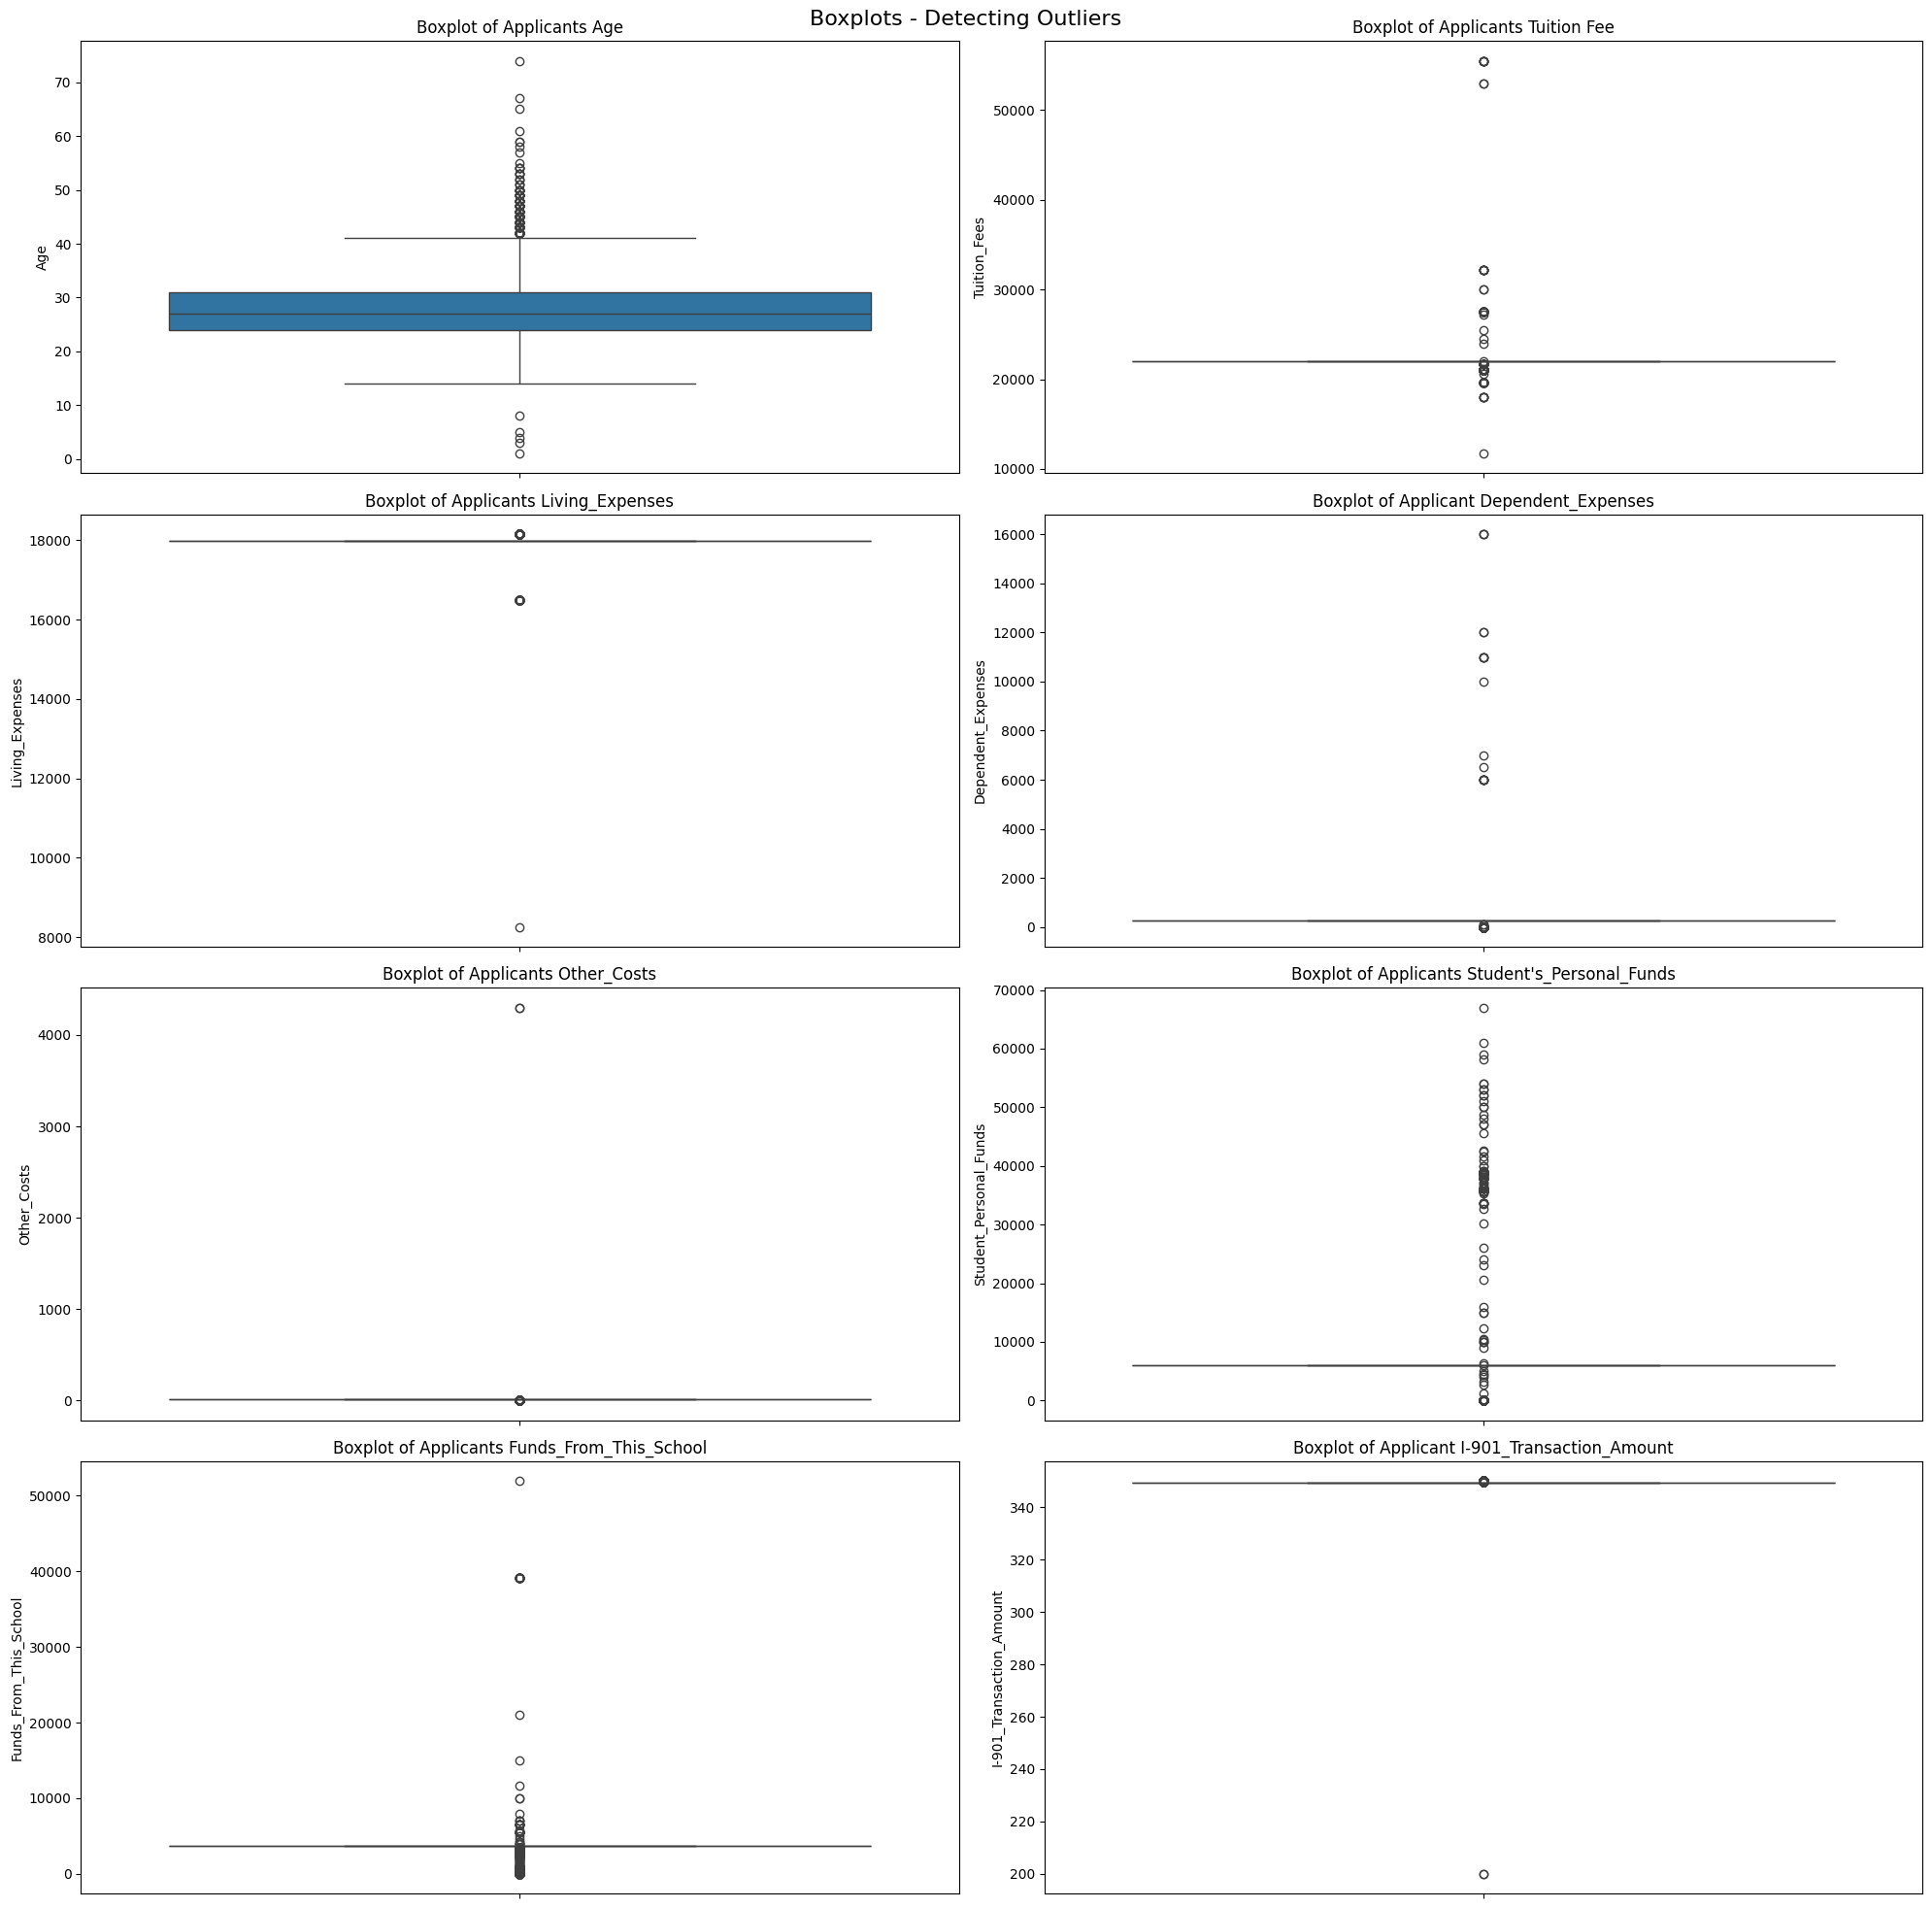

In [37]:
#   Boxplots - Outlier Detection 

print("\nBoxplot of Numerical variables:")

plt.figure(figsize=(20, 20))

plt.subplot(4, 2, 1)
sns.boxplot(y= exc_copied['Age'])
plt.title('Boxplot of Applicants Age')

plt.subplot(4, 2, 2)
sns.boxplot(y=exc_copied['Tuition_Fees'])
plt.title('Boxplot of Applicants Tuition Fee')

plt.subplot(4, 2, 3)
sns.boxplot(y=exc_copied['Living_Expenses'])
plt.title('Boxplot of Applicants Living_Expenses')

plt.subplot(4, 2, 4)
sns.boxplot(y=exc_copied['Dependent_Expenses'])
plt.title('Boxplot of Applicant Dependent_Expenses')

plt.subplot(4, 2, 5)
sns.boxplot(y= exc_copied['Other_Costs'])
plt.title('Boxplot of Applicants Other_Costs')

plt.subplot(4, 2, 6)
sns.boxplot(y=exc_copied["Student_Personal_Funds"])
plt.title("Boxplot of Applicants Student's_Personal_Funds")

plt.subplot(4, 2, 7)
sns.boxplot(y=exc_copied['Funds_From_This_School'])
plt.title('Boxplot of Applicants Funds_From_This_School')

plt.subplot(4, 2, 8)
sns.boxplot(y=exc_copied['I-901_Transaction_Amount'])
plt.title('Boxplot of Applicant I-901_Transaction_Amount')

plt.suptitle('Boxplots - Detecting Outliers', fontsize=16)
plt.tight_layout()
#plt.savefig('boston_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()


Correlation heatmap of numerical variables:


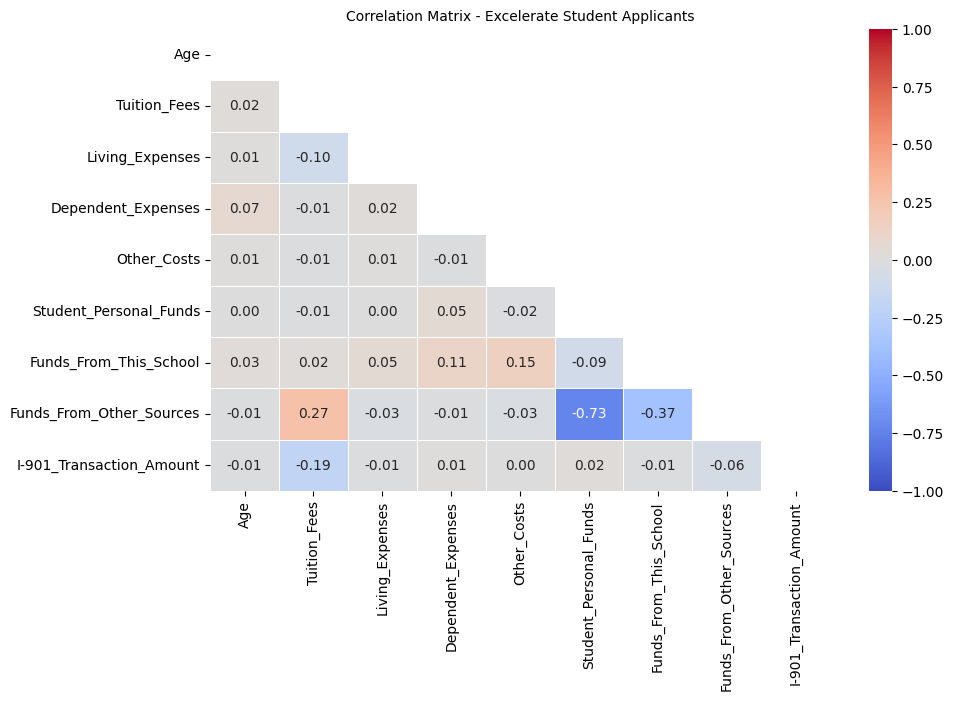

In [38]:
#  Correlation Heatmap

print("\nCorrelation heatmap of numerical variables:")

numerical_cols = ['Age', 'Tuition_Fees', 'Living_Expenses', 
                  'Dependent_Expenses', 'Other_Costs', 
                  "Student_Personal_Funds", 
                  'Funds_From_This_School', 
                  'Funds_From_Other_Sources', 
                  'I-901_Transaction_Amount']

plt.figure(figsize=(10, 6))
corr = exc_copied[numerical_cols].corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5
)

plt.title('Correlation Matrix - Excelerate Student Applicants', fontsize=10)
#plt.savefig('boston_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

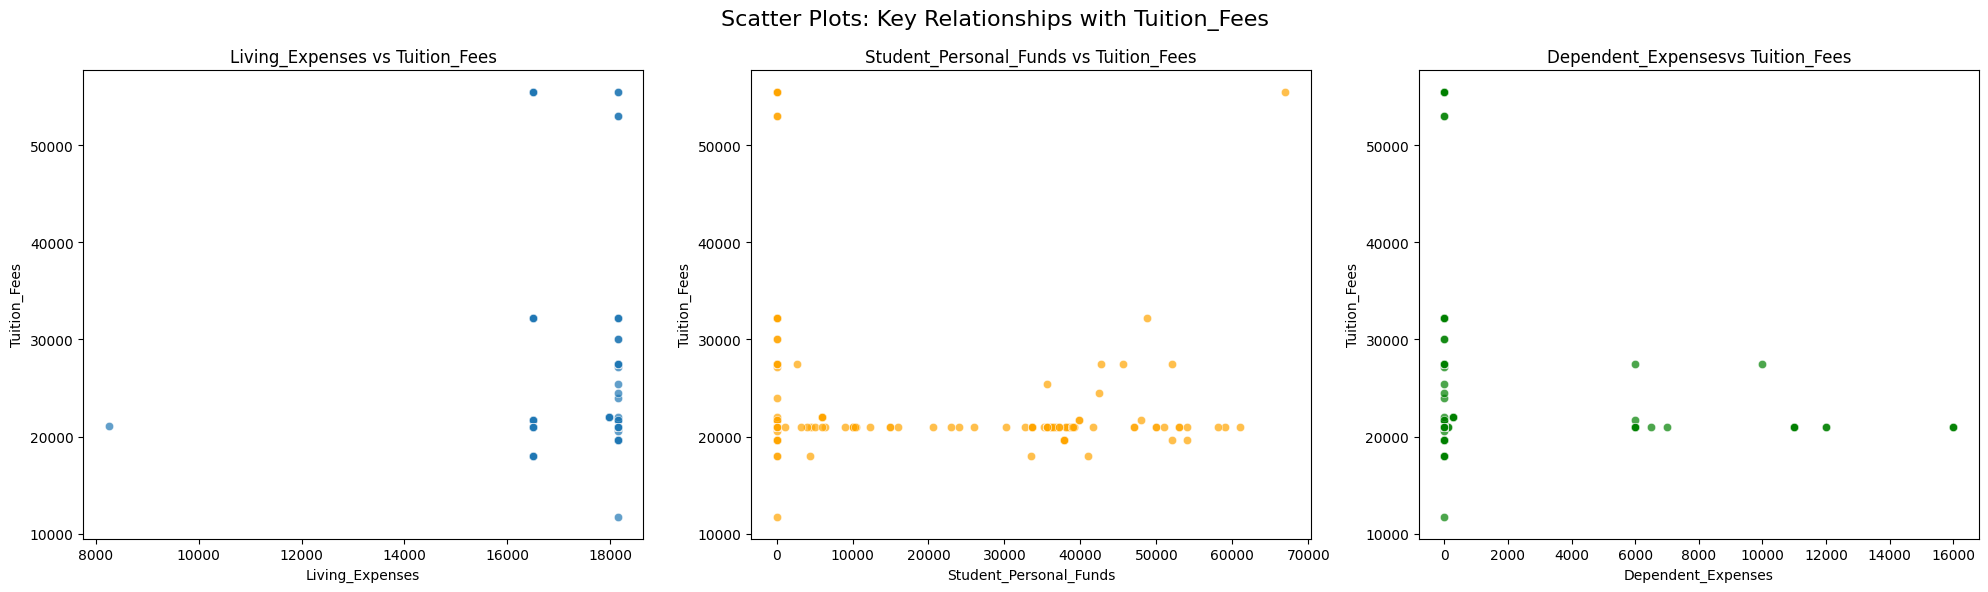

In [39]:
plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x='Living_Expenses', y='Tuition_Fees', data=exc_copied, alpha=0.7)
plt.title('Living_Expenses vs Tuition_Fees')
plt.xlabel('Living_Expenses')
plt.ylabel('Tuition_Fees')

plt.subplot(1, 3, 2)
sns.scatterplot(x="Student_Personal_Funds", y='Tuition_Fees', data=exc_copied, alpha=0.7, color='orange')
plt.title("Student_Personal_Funds vs Tuition_Fees")
plt.xlabel("Student_Personal_Funds")
plt.ylabel('Tuition_Fees')

plt.subplot(1, 3, 3)
sns.scatterplot(x='Dependent_Expenses', y='Tuition_Fees', data=exc_copied, alpha=0.7, color='green')
plt.title('Dependent_Expensesvs Tuition_Fees')
plt.xlabel('Dependent_Expenses')
plt.ylabel('Tuition_Fees')

plt.suptitle('Scatter Plots: Key Relationships with Tuition_Fees', fontsize=16)
plt.tight_layout()
#plt.savefig('boston_scatter_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# Visualization


Number of applicants by Gender:


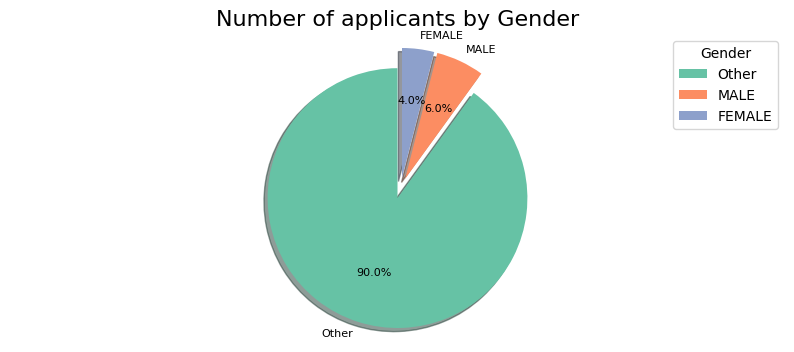

Gender
Other     6205
MALE       413
FEMALE     275
Name: Number of applicants, dtype: int64

In [11]:
 
# Number of applicants by Gender

print("\nNumber of applicants by Gender:")

plt.figure(figsize=(10, 4))

gender_count = exc_copied.groupby(
    'Gender', observed=False
    )['Reference_ID'].count().rename('Number of applicants').sort_values(ascending=False)

plt.pie(
    gender_count.values,                    
    labels=gender_count.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("Set2"),       
    startangle=90,
    explode=[0.08] * len(gender_count),     
    shadow=True,                            
    textprops={'fontsize': 8}
)

plt.title("Number of applicants by Gender", fontsize=16)
plt.legend(gender_count.index, title="Gender", loc="best")
plt.axis('equal')
plt.show()

gender_count


Number of applicants by Departments:


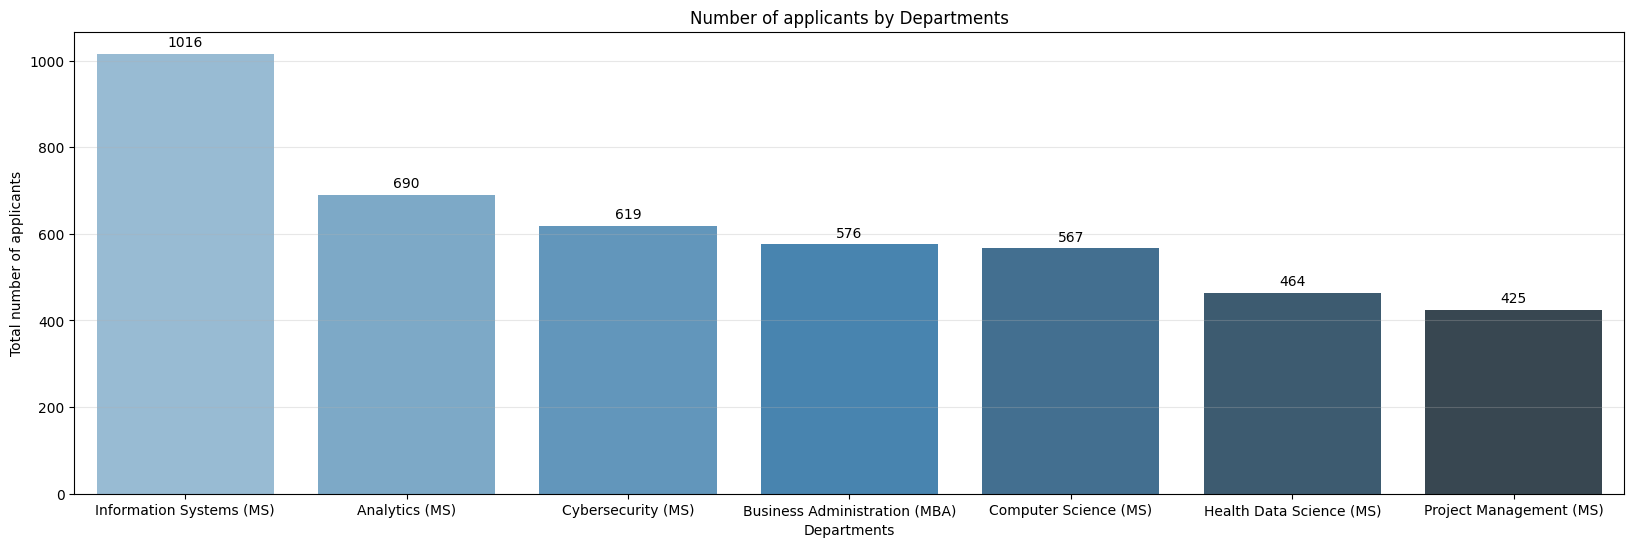

Departments
Information Systems (MS)         1016
Analytics (MS)                    690
Cybersecurity (MS)                619
Business Administration (MBA)     576
Computer Science (MS)             567
Health Data Science (MS)          464
Project Management (MS)           425
Name: Number of applicants, dtype: int64

In [12]:
# Number of applicants by Departments

print("\nNumber of applicants by Departments:")

plt.figure(figsize=(20, 6))
department_count = exc_copied.groupby(
    'Departments', observed=False
    )['Reference_ID'].count().rename('Number of applicants').sort_values(ascending=False).head(7)

ax = sns.barplot(x=department_count.index, 
            y=department_count.values, 
            hue=department_count.index, 
            palette='Blues_d', 
            legend=False
)

# Adding value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
    
plt.title('Number of applicants by Departments')
plt.xlabel('Departments')
plt.ylabel('Total number of applicants')
plt.grid(axis='y', alpha=0.3)
#plt.savefig('boston_barplot_chas.png', dpi=300, bbox_inches='tight')
plt.show()

department_count


Number of applicants by Student_Status:


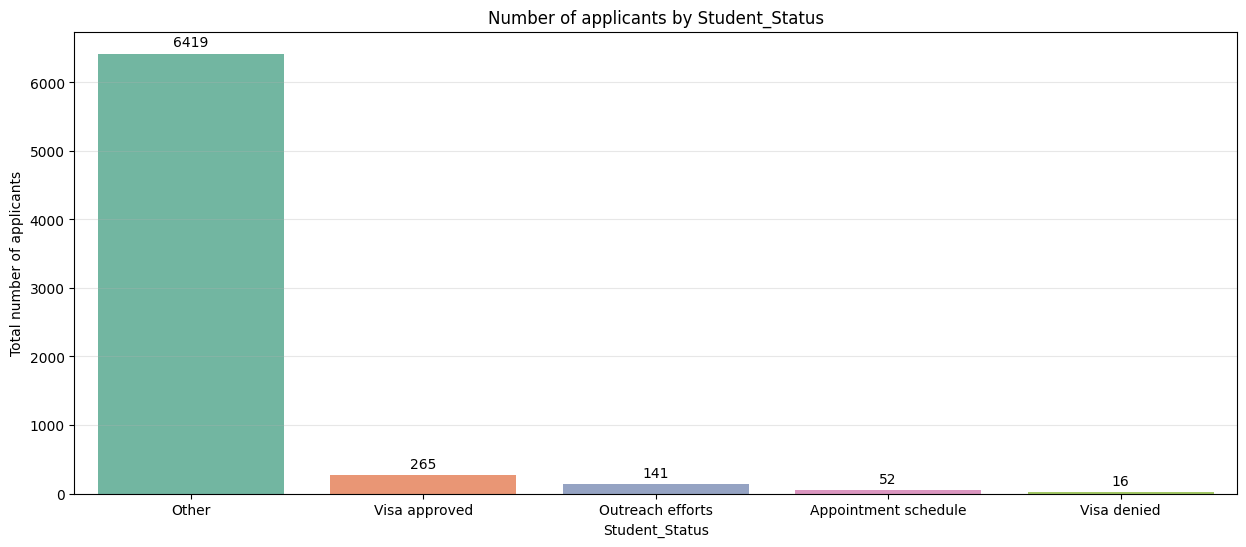

Student_Status
Other                   6419
Visa approved            265
Outreach efforts         141
Appointment schedule      52
Visa denied               16
Name: Number of applicants, dtype: int64

In [13]:
# Number of applicants by Student_Status

print("\nNumber of applicants by Student_Status:")


plt.figure(figsize=(15, 6))
student_status_count = exc_copied.groupby(
    'Student_Status', observed=False
    )['Reference_ID'].count().rename('Number of applicants').sort_values(ascending=False)


ax = sns.barplot(x=student_status_count.index, 
            y=student_status_count.values, 
            hue=student_status_count.index, 
            palette='Set2', 
            legend=False
)

# Adding value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
    
plt.title('Number of applicants by Student_Status')
plt.xlabel('Student_Status')
plt.ylabel('Total number of applicants')
plt.grid(axis='y', alpha=0.3)
#plt.savefig('boston_barplot_chas.png', dpi=300, bbox_inches='tight')
plt.show()


student_status_count


Number of applicants by Citizenship:


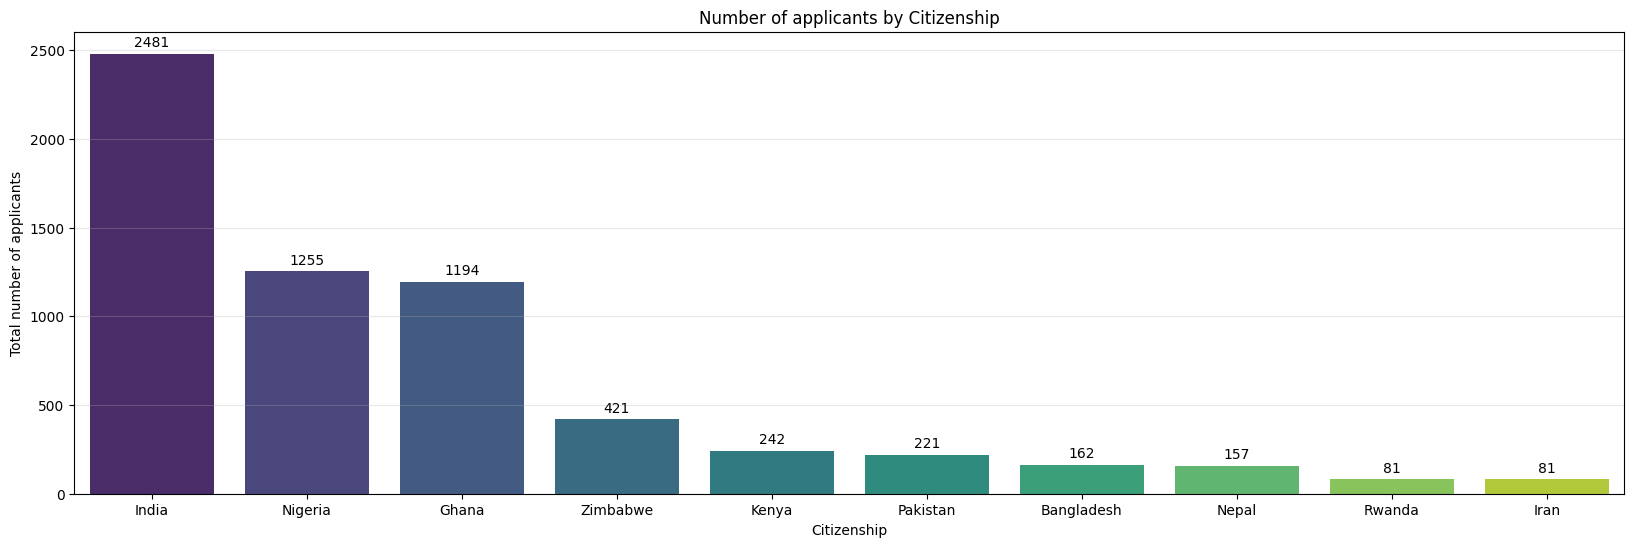

Citizenship
India         2481
Nigeria       1255
Ghana         1194
Zimbabwe       421
Kenya          242
Pakistan       221
Bangladesh     162
Nepal          157
Rwanda          81
Iran            81
Name: Number of applicants, dtype: int64

In [14]:
# Number of applicants by Citizenship

print("\nNumber of applicants by Citizenship:")


plt.figure(figsize=(20, 6))
citizenship_count = exc_copied.groupby(
    'Citizenship', observed=False
    )['Reference_ID'].count().rename('Number of applicants').sort_values(ascending=False).head(10)


ax = sns.barplot(x=citizenship_count.index, 
            y=citizenship_count.values, 
            hue=citizenship_count.index, 
            palette='viridis', 
            legend=False
)

# Adding value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
    
plt.title('Number of applicants by Citizenship')
plt.xlabel('Citizenship')
plt.ylabel('Total number of applicants')
plt.grid(axis='y', alpha=0.3)
#plt.savefig('boston_barplot_chas.png', dpi=300, bbox_inches='tight')
plt.show()


citizenship_count

In [15]:
# Map of citizenship


import plotly.express as px
from pycountry import countries   


print("\nMap of citizenship:")

country_count = exc_copied['Citizenship'].value_counts().reset_index()
country_count.columns = ['Citizenship', 'Count']   

def get_iso3(country_name):
    try:
        return countries.get(name=country_name).alpha_3
    except:
        return None   

country_count['iso_alpha'] = country_count['Citizenship'].apply(get_iso3)


country_count = country_count.dropna(subset=['iso_alpha'])


fig = px.choropleth(
    country_count,
    locations='Citizenship',           # Column with country names
    locationmode='country names',  
    color='Count',                 
    hover_name='Citizenship',
    color_continuous_scale='thermal',   
    title='Number of Applicants by Citizenship',
    height=650
)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    title_font_size=16
)

fig.show()


Map of citizenship:


In [16]:
#'tealrose', 'tempo', 'temps', 'thermal', 'tropic', 'turbid',
             #'turbo', 'twilight', 'viridis', 'ylgn', 'ylgnbu', 'ylorbr',
             #'ylorrd'


Number of applicants by Intake:


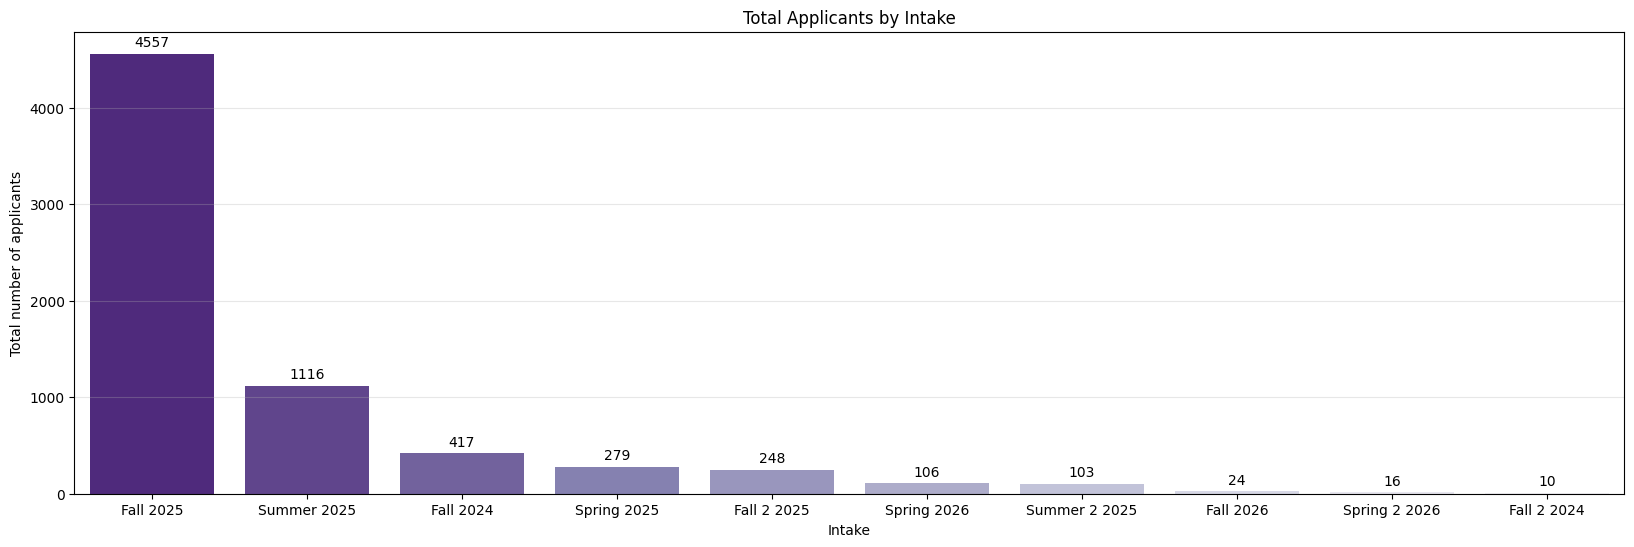

Intake
Fall 2025        4557
Summer 2025      1116
Fall 2024         417
Spring 2025       279
Fall 2 2025       248
Spring 2026       106
Summer 2 2025     103
Fall 2026          24
Spring 2 2026      16
Fall 2 2024        10
Name: Number of applicants, dtype: int64

In [17]:
# Number of applicants by Intake

print("\nNumber of applicants by Intake:")

plt.figure(figsize=(20, 6))
intake_count = exc_copied.groupby(
    'Intake', observed=False
    )['Reference_ID'].count().rename( 'Number of applicants').sort_values(ascending=False).head(10)


ax = sns.barplot(x=intake_count.index, 
            y=intake_count.values, 
            hue=intake_count.index, 
            palette='Purples_r', 
            legend=False
)

# Adding value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
    
    
plt.title('Total Applicants by Intake')
plt.xlabel('Intake')
plt.ylabel('Total number of applicants')
plt.grid(axis='y', alpha=0.3)
#plt.savefig('boston_barplot_chas.png', dpi=300, bbox_inches='tight')
plt.show()


intake_count 

In [18]:
# Creating Age group column

exc_copied.loc[exc_copied["Age"] >= 60, "Age_group"] = "Old Age"
exc_copied.loc[(exc_copied["Age"] >= 40) & (exc_copied["Age"] < 60), "Age_group"] = "Middle Age"
exc_copied.loc[(exc_copied["Age"] >= 20) & (exc_copied["Age"] < 40), "Age_group"] = "Adult"
exc_copied.loc[exc_copied["Age"] < 20, "Age_group"] = "Young Adult"


Number of applicants by Age Group:


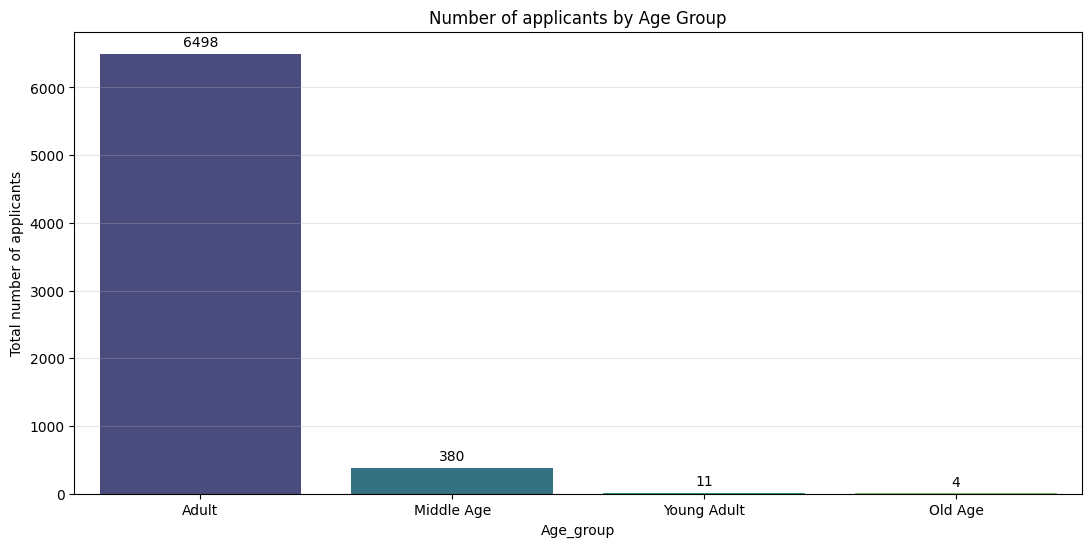

Age_group
Adult          6498
Middle Age      380
Young Adult      11
Old Age           4
Name: Number of applicants, dtype: int64

In [19]:
# Number of applicants by Age Group

print("\nNumber of applicants by Age Group:")

plt.figure(figsize=(13, 6))
Age_count = exc_copied.groupby(
    'Age_group', observed=False
    )['Reference_ID'].count().rename( 'Number of applicants').sort_values(ascending=False)

ax = sns.barplot(x=Age_count.index, 
            y=Age_count.values, 
            hue=Age_count.index, 
            palette='viridis', 
            legend=False
)

# Adding value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
    
    
plt.title('Number of applicants by Age Group')
plt.xlabel('Age_group')
plt.ylabel('Total number of applicants')
plt.grid(axis='y', alpha=0.3)
#plt.savefig('boston_barplot_chas.png', dpi=300, bbox_inches='tight')
plt.show()

Age_count


Number of applicants by Program of interest:


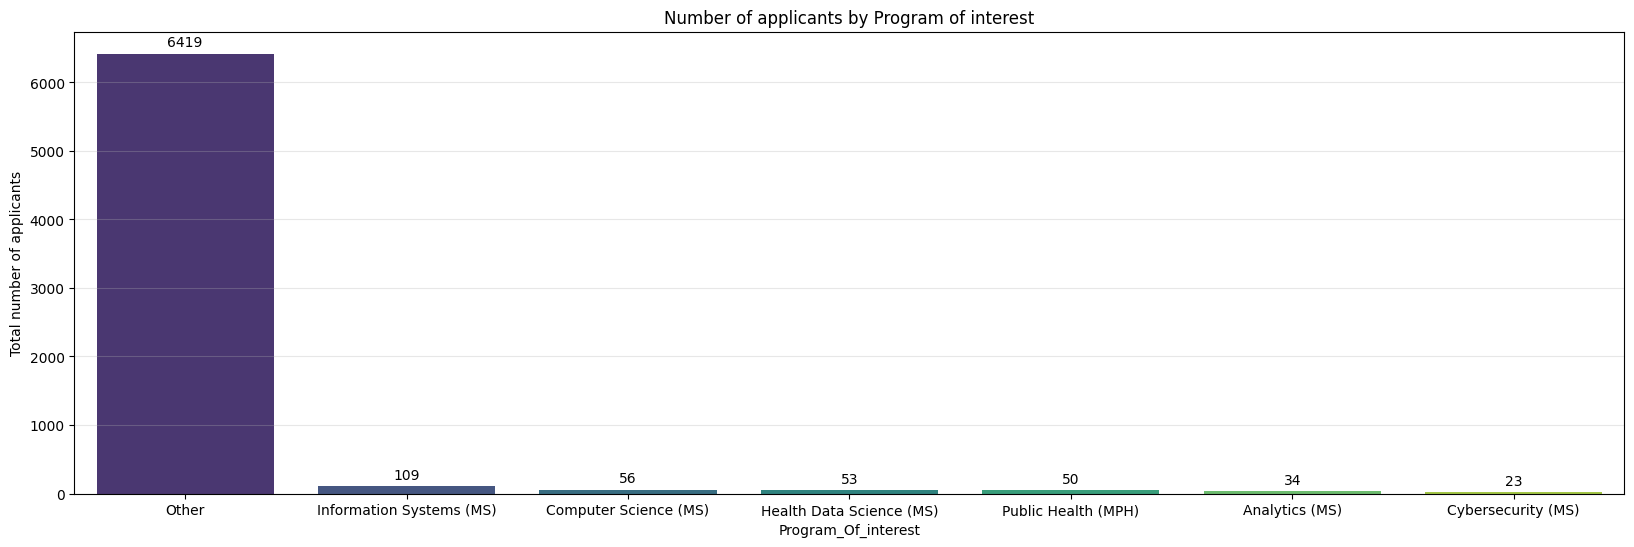

Program_Of_interest
Other                       6419
Information Systems (MS)     109
Computer Science (MS)         56
Health Data Science (MS)      53
Public Health (MPH)           50
Analytics (MS)                34
Cybersecurity (MS)            23
Name: Number of applicants, dtype: int64

In [20]:
# Number of applicants by Program of interest

print("\nNumber of applicants by Program of interest:")


plt.figure(figsize=(20, 6))
Program_count = exc_copied.groupby(
    'Program_Of_interest', observed=False
    )['Reference_ID'].count().rename( 'Number of applicants').sort_values(ascending=False).head(7)

ax = sns.barplot(x=Program_count.index, 
            y=Program_count.values, 
            hue=Program_count.index, 
            palette='viridis', 
            legend=False
)

# Adding value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
    
    
plt.title('Number of applicants by Program of interest')
plt.xlabel('Program_Of_interest')
plt.ylabel('Total number of applicants')
plt.grid(axis='y', alpha=0.3)
#plt.savefig('boston_barplot_chas.png', dpi=300, bbox_inches='tight')
plt.show()


Program_count


Number of applicants by Education Level:


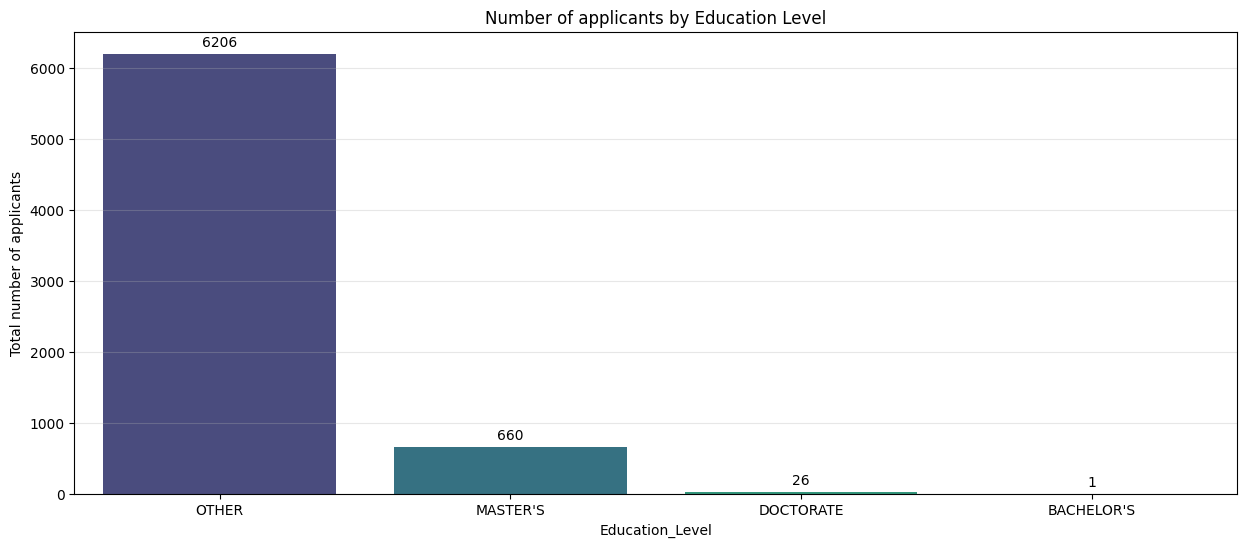

Education_Level
OTHER         6206
MASTER'S       660
DOCTORATE       26
BACHELOR'S       1
Name: Reference_ID, dtype: int64

In [21]:
# Number of applicants by Education Level

print("\nNumber of applicants by Education Level:")


plt.figure(figsize=(15, 6))
Education_Level_count = exc_copied.groupby(
    'Education_Level', observed=False
    )['Reference_ID'].count().sort_values(ascending=False)

ax= sns.barplot(x=Education_Level_count.index, 
            y=Education_Level_count.values, 
            hue=Education_Level_count.index, 
            palette='viridis', 
            legend=False
)

# Adding value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
    
    
plt.title('Number of applicants by Education Level')
plt.xlabel('Education_Level')
plt.ylabel('Total number of applicants')
plt.grid(axis='y', alpha=0.3)
#plt.savefig('boston_barplot_chas.png', dpi=300, bbox_inches='tight')
plt.show()

Education_Level_count

In [22]:
exc_copied.loc[exc_copied['School_Fund_Type'] == 'Graduate Assistantship, Tuition, Health Insurance, Stipend', 'School_Fund_Type'] = 'Assistantship'


exc_copied.loc[exc_copied['School_Fund_Type'] == 'scholarship', 'School_Fund_Type'] = 'Scholarship'

exc_copied.loc[exc_copied['School_Fund_Type'] == 'Graduate assistantship', 'School_Fund_Type'] = 'Assistantship'

exc_copied.loc[exc_copied['School_Fund_Type'] == 'Global Graduate Scholarship', 'School_Fund_Type'] = 'Scholarship'

exc_copied.loc[exc_copied['School_Fund_Type'] == 'Graduate Assistantship', 'School_Fund_Type'] = 'Assistantship'

exc_copied.loc[exc_copied['School_Fund_Type'] == 'Teaching Assistantship', 'School_Fund_Type'] = 'Assistantship'

exc_copied.loc[exc_copied['School_Fund_Type'] == 'Research Assistantship - Full tuition and stipend', 'School_Fund_Type'] = 'Assistantship'


Number of applicants by School_Fund_Type:


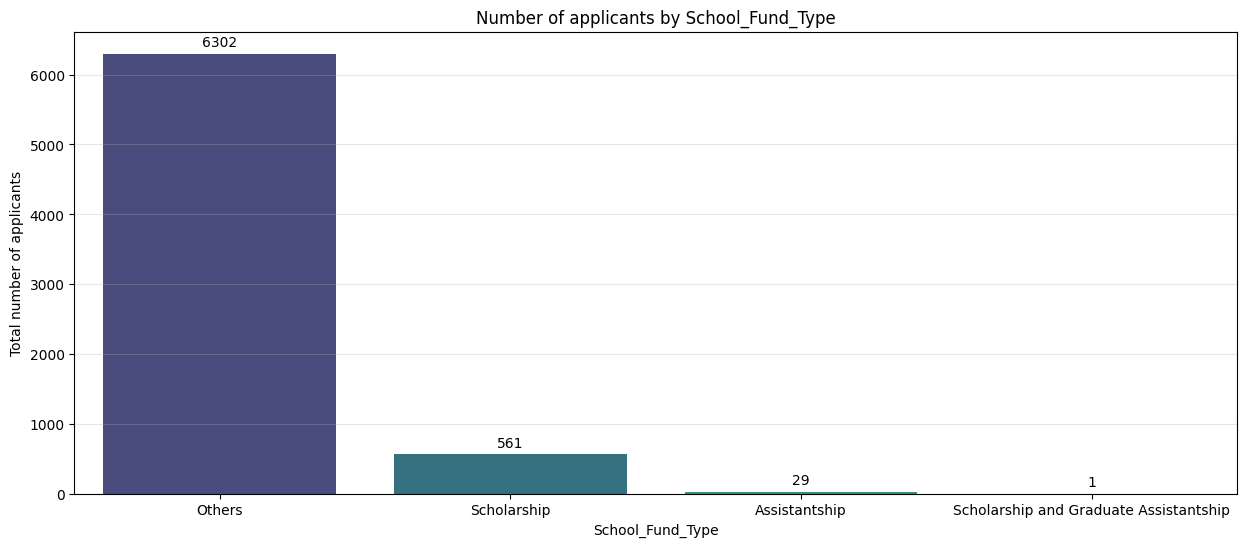

School_Fund_Type
Others                                    6302
Scholarship                                561
Assistantship                               29
Scholarship and Graduate Assistantship       1
Name: Reference_ID, dtype: int64

In [23]:
# Number of applicants by School_Fund_Type


print("\nNumber of applicants by School_Fund_Type:")

plt.figure(figsize=(15, 6))
School_Fund_Type_count = exc_copied.groupby(
    'School_Fund_Type', observed=False
    )['Reference_ID'].count().sort_values(ascending=False)

ax = sns.barplot(x=School_Fund_Type_count.index, 
            y=School_Fund_Type_count.values, 
            hue=School_Fund_Type_count.index, 
            palette='viridis', 
            legend=False
)

# Adding value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
    
    
plt.title('Number of applicants by School_Fund_Type')
plt.xlabel('School_Fund_Type')
plt.ylabel('Total number of applicants')
plt.grid(axis='y', alpha=0.3)
#plt.savefig('boston_barplot_chas.png', dpi=300, bbox_inches='tight')
plt.show()

School_Fund_Type_count


Average Tuition Fees by Departments:


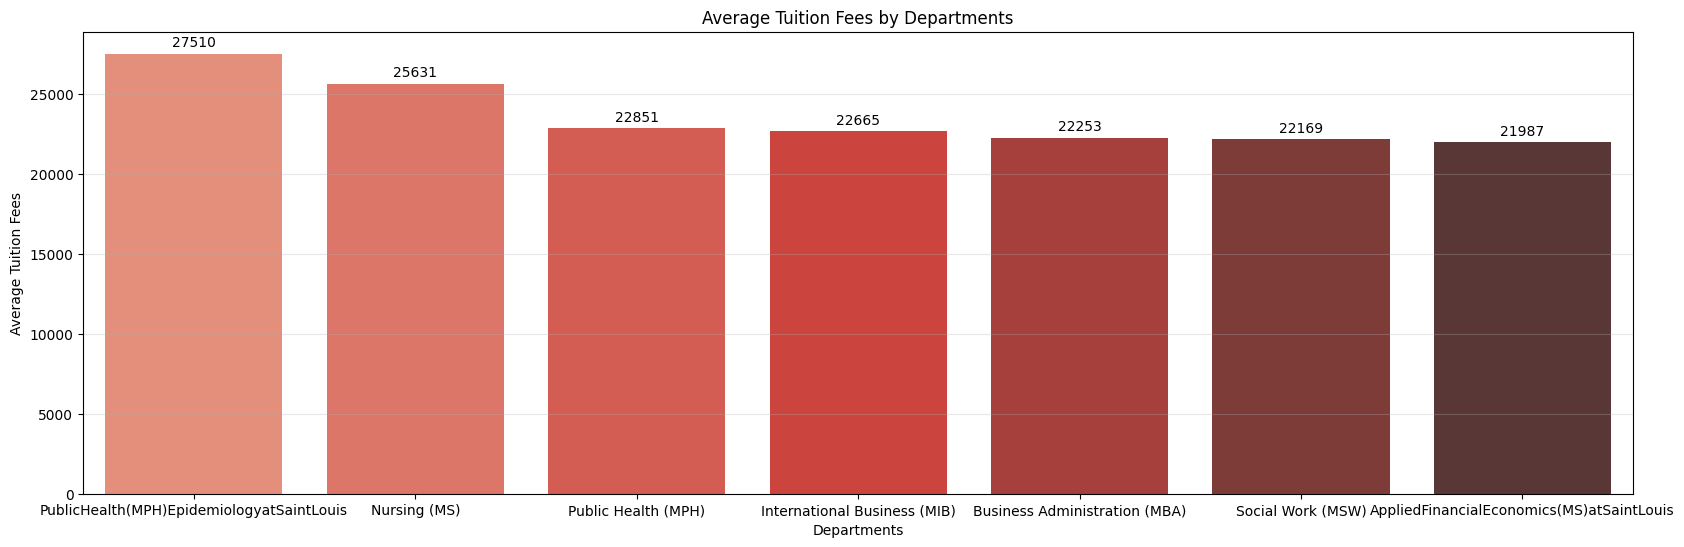

Departments
PublicHealth(MPH)EpidemiologyatSaintLouis    27510.00
Nursing (MS)                                 25631.22
Public Health (MPH)                          22850.70
International Business (MIB)                 22665.39
Business Administration (MBA)                22252.89
Social Work (MSW)                            22168.83
AppliedFinancialEconomics(MS)atSaintLouis    21986.71
Name: Average Tuition Fees, dtype: float64

In [24]:
# Average Tuition Fees by Departments


plt.figure(figsize=(20, 6))
department_Tuition= exc_copied.groupby(
    'Departments', observed=False
    )['Tuition_Fees'].mean().round(2).rename('Average Tuition Fees').sort_values(ascending=False).head(7)

ax = sns.barplot(x=department_Tuition.index, 
            y=department_Tuition.values, 
            hue=department_Tuition.index, 
            palette='Reds_d', 
            legend=False
)

# Adding value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
    
    
print("\nAverage Tuition Fees by Departments:")

plt.title('Average Tuition Fees by Departments')
plt.xlabel('Departments')
plt.ylabel('Average Tuition Fees')
plt.grid(axis='y', alpha=0.3)
#plt.savefig('boston_barplot_chas.png', dpi=300, bbox_inches='tight')
plt.show()

department_Tuition


Average Tuition Fees by Citizenship:


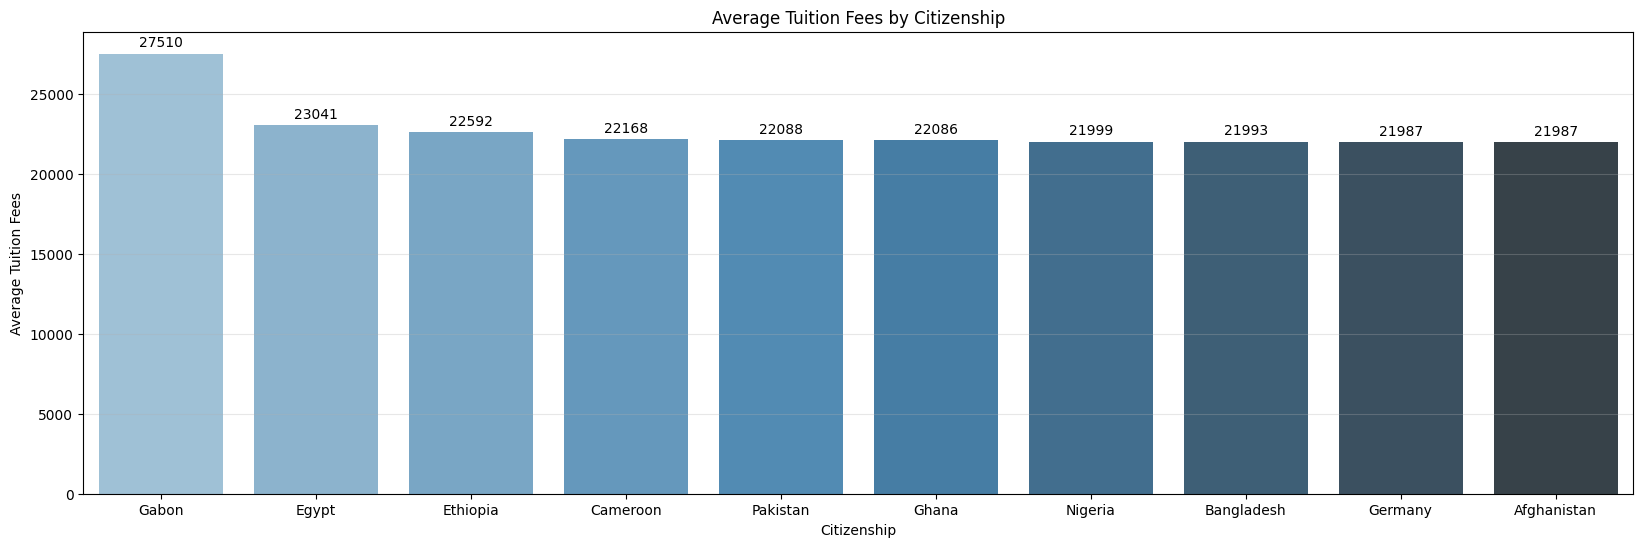

Citizenship
Gabon          27510.00
Egypt          23040.83
Ethiopia       22591.90
Cameroon       22168.46
Pakistan       22088.09
Ghana          22086.03
Nigeria        21999.25
Bangladesh     21993.34
Germany        21986.71
Afghanistan    21986.71
Name: Average Tuition Fees, dtype: float64

In [25]:
# Average Tuition Fees by Citizenship


plt.figure(figsize=(20, 6))
citizenship_Tuition= exc_copied.groupby(
    'Citizenship', observed=False
    )['Tuition_Fees'].mean().round(2).rename('Average Tuition Fees').sort_values(ascending=False).head(10)

ax = sns.barplot(x=citizenship_Tuition.index, 
            y=citizenship_Tuition.values, 
            hue=citizenship_Tuition.index, 
            palette='Blues_d', 
            legend=False
)

# Adding value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
    

print("\nAverage Tuition Fees by Citizenship:")

plt.title('Average Tuition Fees by Citizenship')
plt.xlabel('Citizenship')
plt.ylabel('Average Tuition Fees')
plt.grid(axis='y', alpha=0.3)

plt.show()

citizenship_Tuition


Average Tuition Fees by Intake:


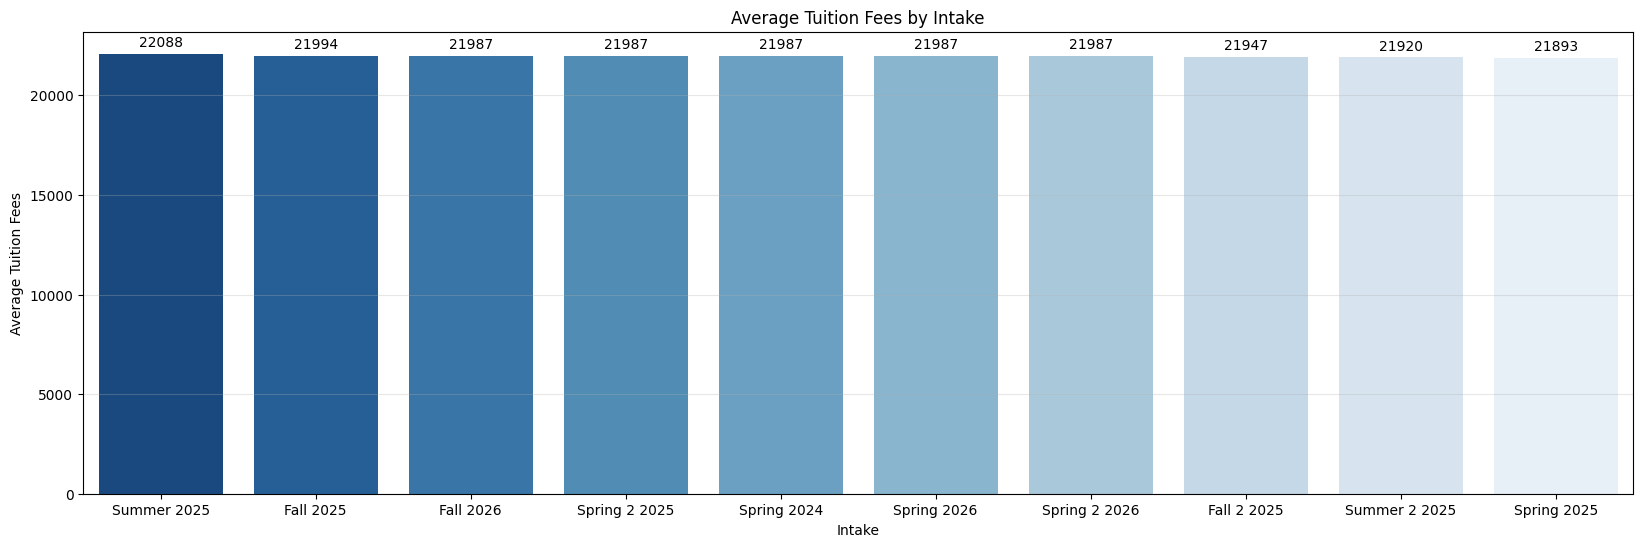

Intake
Summer 2025      22087.84
Fall 2025        21994.46
Fall 2026        21986.71
Spring 2 2025    21986.71
Spring 2024      21986.71
Spring 2026      21986.71
Spring 2 2026    21986.71
Fall 2 2025      21946.77
Summer 2 2025    21919.66
Spring 2025      21892.85
Name: Average Tuition Fees, dtype: float64

In [26]:
# Average Tuition Fees by Intake


plt.figure(figsize=(20, 6))
intake_Tuition= exc_copied.groupby(
    'Intake', observed=False
    )['Tuition_Fees'].mean().round(2).rename('Average Tuition Fees').sort_values(ascending=False).head(10)

ax = sns.barplot(x=intake_Tuition.index, 
            y=intake_Tuition.values, 
            hue=intake_Tuition.index, 
            palette='Blues_r', 
            legend=False
)

# Adding value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
    

print("\nAverage Tuition Fees by Intake:")

plt.title('Average Tuition Fees by Intake')
plt.xlabel('Intake')
plt.ylabel('Average Tuition Fees')
plt.grid(axis='y', alpha=0.3)

plt.show()

intake_Tuition


Average Living_Expenses by Citizenship:


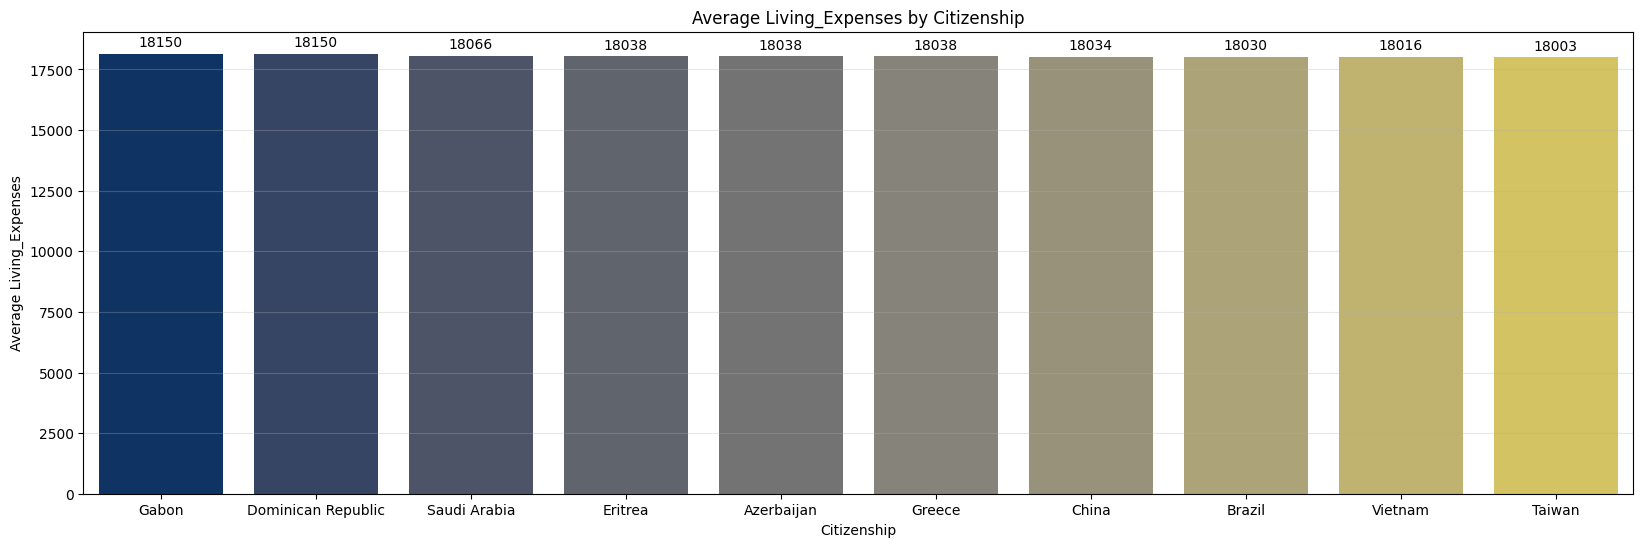

Citizenship
Gabon                 18150.00
Dominican Republic    18150.00
Saudi Arabia          18066.06
Eritrea               18038.08
Azerbaijan            18038.08
Greece                18038.08
China                 18034.08
Brazil                18030.09
Vietnam               18015.70
Taiwan                18003.11
Name: Average Living_Expenses, dtype: float64

In [27]:

# Average Living_Expenses by Citizenship

plt.figure(figsize=(20, 6))
citizenship_Living_Expenses= exc_copied.groupby(
    'Citizenship', observed=False
    )['Living_Expenses'].mean().round(2).rename('Average Living_Expenses').sort_values(ascending=False).head(10)

ax = sns.barplot(x=citizenship_Living_Expenses.index, 
            y=citizenship_Living_Expenses.values, 
            hue=citizenship_Living_Expenses.index, 
            palette='cividis', 
            legend=False
)

# Adding value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
    
    
print("\nAverage Living_Expenses by Citizenship:")

plt.title('Average Living_Expenses by Citizenship')
plt.xlabel('Citizenship')
plt.ylabel('Average Living_Expenses')
plt.grid(axis='y', alpha=0.3)

plt.show()

citizenship_Living_Expenses


Number of applicants by School_Fund_Type:


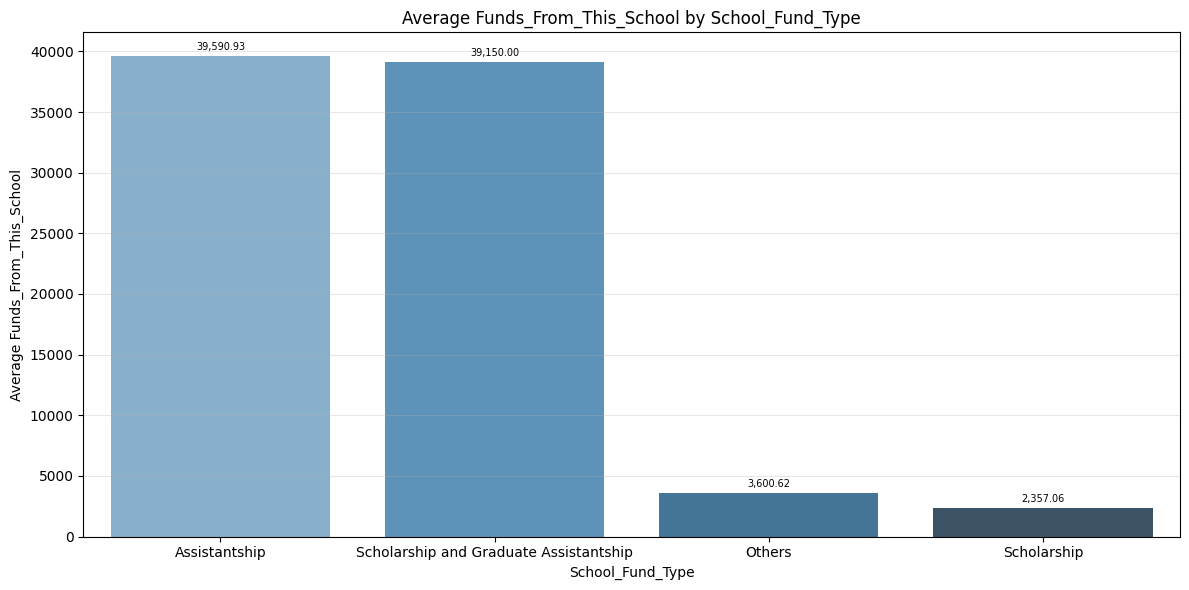

School_Fund_Type
Assistantship                             39590.93
Scholarship and Graduate Assistantship    39150.00
Others                                     3600.62
Scholarship                                2357.06
Name: Average Funds_From_This_School, dtype: float64

In [28]:
# Average Funds_From_This_School by School_Fund_Type


print("\nNumber of applicants by School_Fund_Type:")

plt.figure(figsize=(12, 6))
School_Fund_Type_avg = exc_copied.groupby(
    'School_Fund_Type', observed=False
    )['Funds_From_This_School'].mean().sort_values(ascending=False).rename('Average Funds_From_This_School').round(2).head(5)

ax = sns.barplot(x=School_Fund_Type_avg.index, 
            y=School_Fund_Type_avg.values, 
            hue=School_Fund_Type_avg.index, 
            palette='Blues_d', 
            legend=False
)
plt.title('Average Funds_From_This_School by School_Fund_Type')
plt.xlabel('School_Fund_Type')
plt.ylabel('Average Funds_From_This_School')
plt.grid(axis='y', alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, 
                 fmt='{:,.2f}',      
                 padding=3, 
                 fontsize=7,
                 fontweight='light'
                 )

plt.tight_layout()
plt.show()

School_Fund_Type_avg

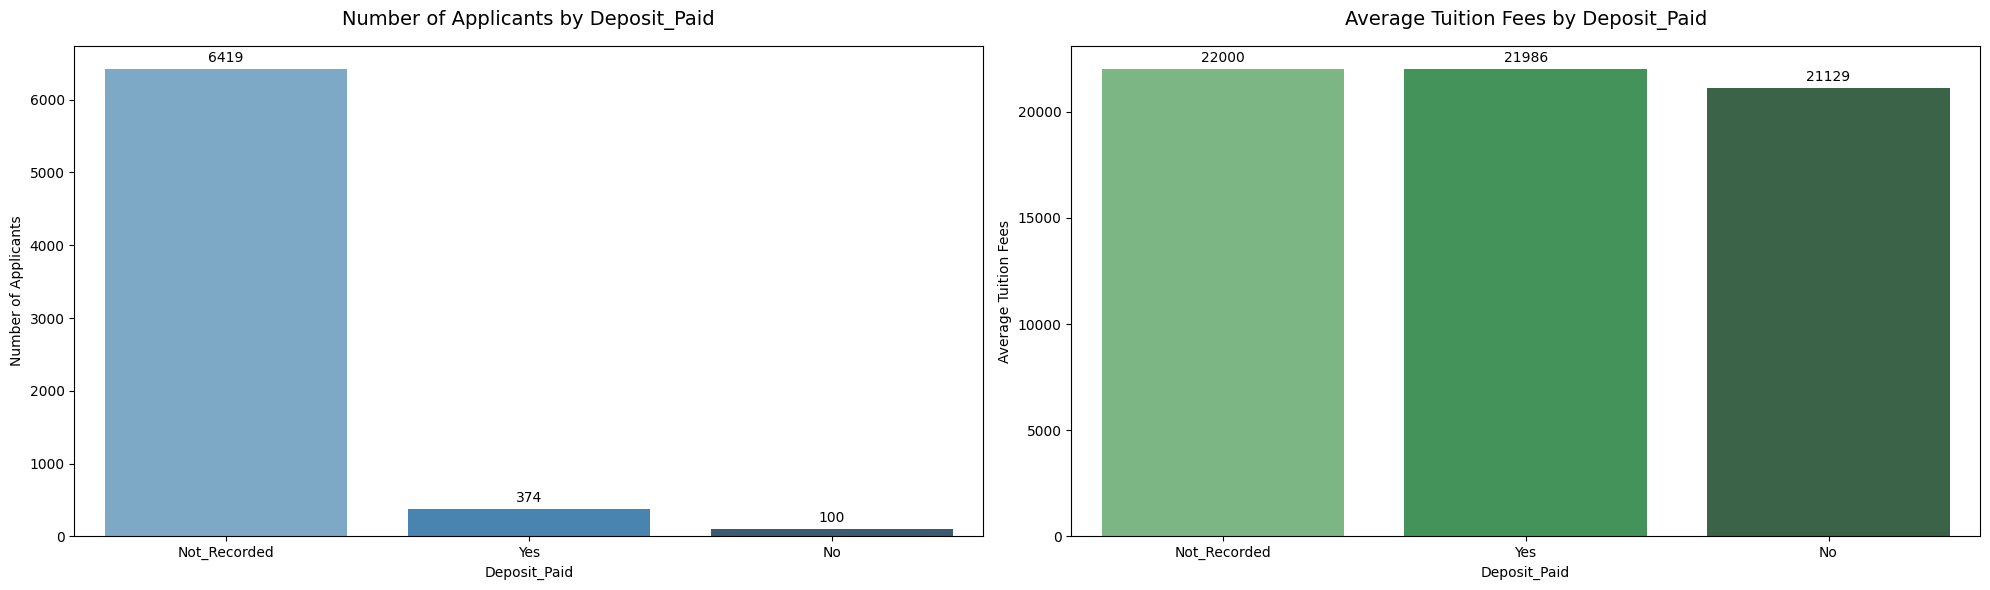

,Average_Tuition_Fees,Number_of_Applicants
Deposit_Paid,,
Not_Recorded,22000.11,6419
Yes,21986.16,374
No,21128.66,100


In [29]:
# Number of Applicants VS Average_Tuition_Fees by Deposit_Paid


Deposit_Paid_var = exc_copied.groupby(
    "Deposit_Paid", observed=False).agg({
    "Tuition_Fees": "mean",
    "Reference_ID": "count"}).rename(columns={
        "Tuition_Fees": "Average_Tuition_Fees",
        "Reference_ID": "Number_of_Applicants"
    }).sort_values(by="Average_Tuition_Fees", ascending=False).round(2)
    
    
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.barplot(
    data=Deposit_Paid_var.reset_index(),
    x="Deposit_Paid", 
    y="Number_of_Applicants", 
    hue="Deposit_Paid", 
    palette='Blues_d', 
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Number of Applicants by Deposit_Paid', fontsize=14, pad=15)
axes[0].set_xlabel('Deposit_Paid')
axes[0].set_ylabel('Number of Applicants')
axes[0].tick_params(axis='x')

# Adding value labels on top of bars
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', padding=3)
    


# Chart 2: Average Tuition Fees

sns.barplot(
    data=Deposit_Paid_var.reset_index(),
    x="Deposit_Paid",
    y="Average_Tuition_Fees",
    hue="Deposit_Paid",
    palette="Greens_d",
    legend=False,
    ax=axes[1]
)

axes[1].set_title('Average Tuition Fees by Deposit_Paid', fontsize=14, pad=15)
axes[1].set_xlabel('Deposit_Paid')
axes[1].set_ylabel('Average Tuition Fees')
axes[1].tick_params(axis='x')

# Adding value labels on top of bars
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()
    
Deposit_Paid_var

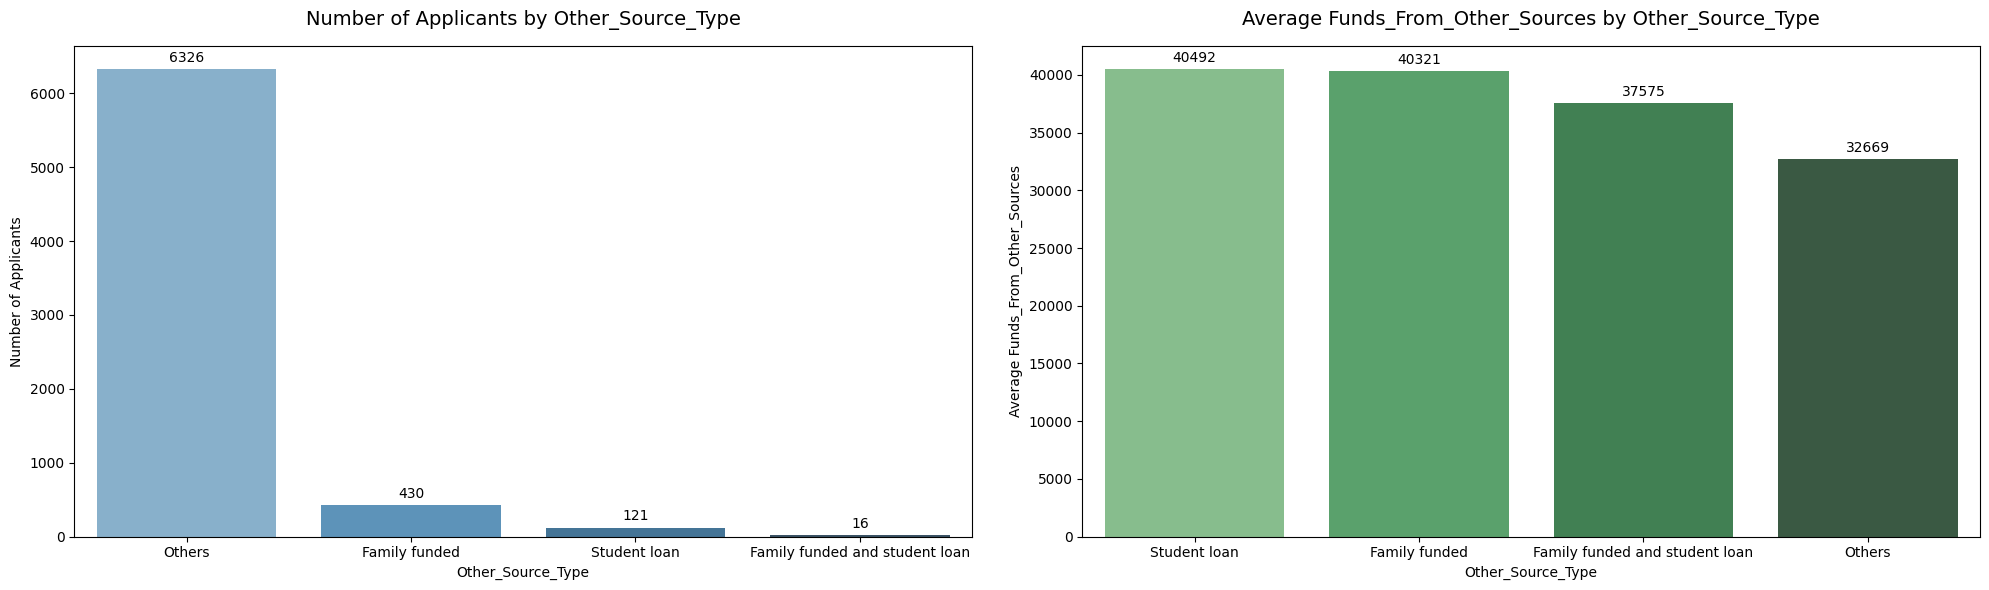

,Average_Funds_From_Other_Sources,Number_of_Applicants
Other_Source_Type,,
Family funded,40321.01,430
Family funded and student loan,37575.00,16
Others,32668.95,6326
Student loan,40491.78,121


In [30]:
# Number of Applicants VS Funds_From_Other_Sources by Other_Source_Type


Other_Source_Type_var = exc_copied.groupby(
    "Other_Source_Type", observed=False).agg({
    "Funds_From_Other_Sources": "mean",
    "Reference_ID": "count"}).rename(columns={
        "Funds_From_Other_Sources": "Average_Funds_From_Other_Sources",
        "Reference_ID": "Number_of_Applicants"
    }).round(2)
    
affos_sorted = Other_Source_Type_var.sort_values(by="Average_Funds_From_Other_Sources", ascending=False)
noa_sorted = Other_Source_Type_var.sort_values(by="Number_of_Applicants", ascending=False)
    
    
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.barplot(
    data=noa_sorted.reset_index(),
    x="Other_Source_Type", 
    y="Number_of_Applicants", 
    hue="Other_Source_Type", 
    palette='Blues_d', 
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Number of Applicants by Other_Source_Type', fontsize=14, pad=15)
axes[0].set_xlabel('Other_Source_Type')
axes[0].set_ylabel('Number of Applicants')
axes[0].tick_params(axis='x')

# Adding value labels on top of bars
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', padding=3)
    


# Chart 2: Average Funds_From_Other_Sources

sns.barplot(
    data=affos_sorted.reset_index(),
    x="Other_Source_Type",
    y="Average_Funds_From_Other_Sources",
    hue="Other_Source_Type",
    palette="Greens_d",
    legend=False,
    ax=axes[1]
)

axes[1].set_title('Average Funds_From_Other_Sources by Other_Source_Type', fontsize=14, pad=15)
axes[1].set_xlabel('Other_Source_Type')
axes[1].set_ylabel('Average Funds_From_Other_Sources')
axes[1].tick_params(axis='x')

# Adding value labels on top of bars
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()
    
Other_Source_Type_var

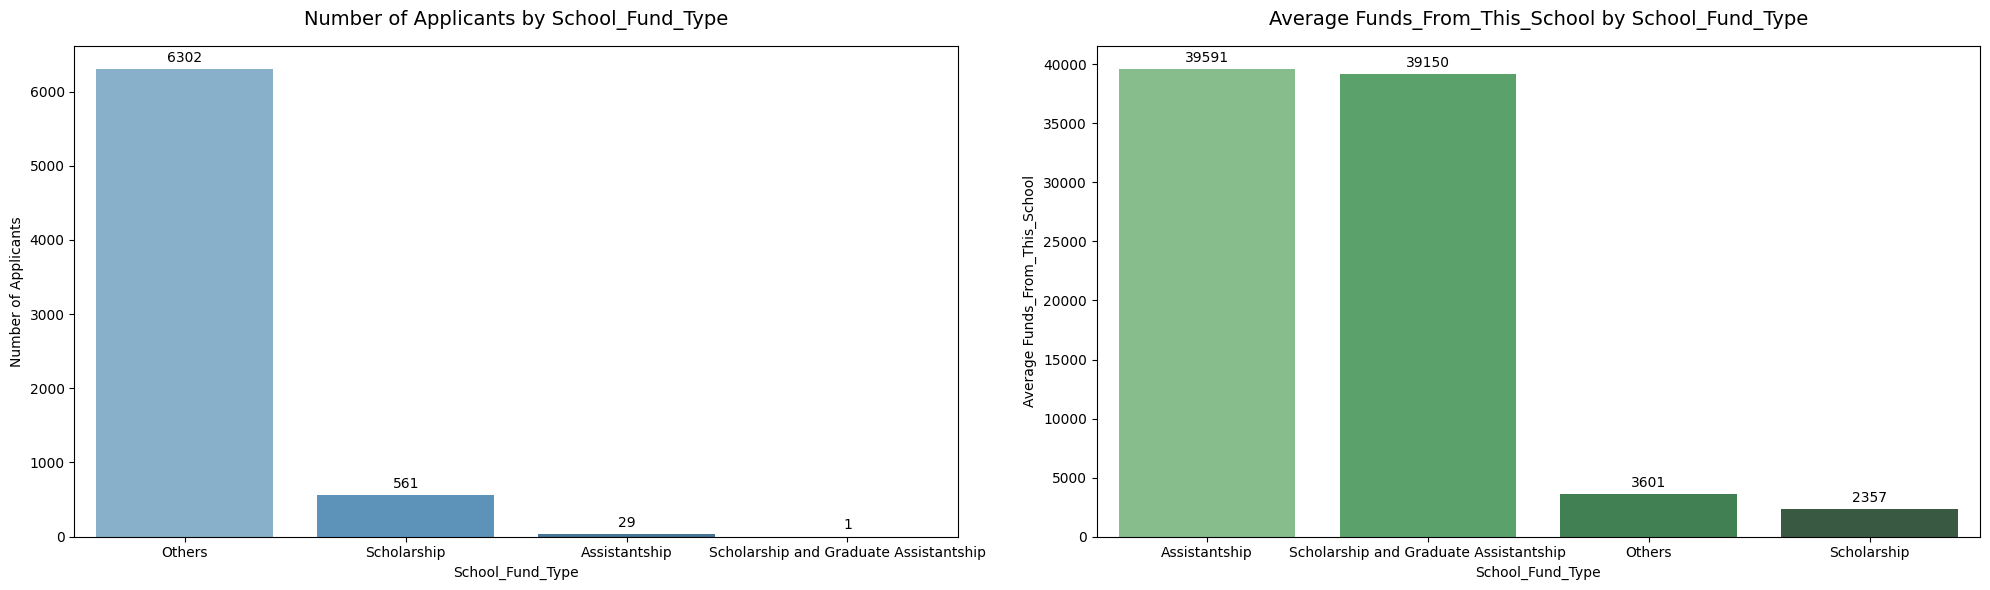

,Average_Funds_From_This_School,Number_of_Applicants
School_Fund_Type,,
Assistantship,39590.93,29
Others,3600.62,6302
Scholarship,2357.06,561
Scholarship and Graduate Assistantship,39150.00,1


In [31]:
# Number of Applicants VS Funds_From_This_School by School_Fund_Type


School_Fund_Type_var = exc_copied.groupby(
    "School_Fund_Type", observed=False).agg({
    "Funds_From_This_School": "mean",
    "Reference_ID": "count"}).rename(columns={
        "Funds_From_This_School": "Average_Funds_From_This_School",
        "Reference_ID": "Number_of_Applicants"
    }).round(2)
    
affts_sorted = School_Fund_Type_var.sort_values(by="Average_Funds_From_This_School", ascending=False)
noa_sorted_ = School_Fund_Type_var.sort_values(by="Number_of_Applicants", ascending=False)
    
    
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.barplot(
    data=noa_sorted_.reset_index(),
    x="School_Fund_Type", 
    y="Number_of_Applicants", 
    hue="School_Fund_Type", 
    palette='Blues_d', 
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Number of Applicants by School_Fund_Type', fontsize=14, pad=15)
axes[0].set_xlabel('School_Fund_Type')
axes[0].set_ylabel('Number of Applicants')
axes[0].tick_params(axis='x')

# Adding value labels on top of bars
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', padding=3)
    


# Chart 2: Average Funds_From_This_School

sns.barplot(
    data=affts_sorted.reset_index(),
    x="School_Fund_Type",
    y="Average_Funds_From_This_School",
    hue="School_Fund_Type",
    palette="Greens_d",
    legend=False,
    ax=axes[1]
)

axes[1].set_title('Average Funds_From_This_School by School_Fund_Type', fontsize=14, pad=15)
axes[1].set_xlabel('School_Fund_Type')
axes[1].set_ylabel('Average Funds_From_This_School')
axes[1].tick_params(axis='x')

# Adding value labels on top of bars
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()
    
School_Fund_Type_var

In [32]:
# Filtering with two columns 
exc_copied.loc[(exc_copied["Age_group"] == 'Adult') & (exc_copied["Citizenship"] == "Nigeria"), 'Tuition_Fees' ].mean().round(2)

np.float64(22005.44)

In [53]:
exc_copied['Phone_Number'].duplicated().sum()

np.int64(159)

In [ ]:
#Export = exc_copied.to_csv("Merged_dataset_updated.csv", index = False)
#Export